In [41]:
import truststore
truststore.inject_into_ssl()

In [42]:
from dotenv import load_dotenv
load_dotenv()

True

In [43]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [44]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundery_percentage: float
    summary: str

In [45]:
def calculate_sr(state: BatsmanState):
    sr = (state['runs']/state['balls'])*100
    return {'sr': sr}

In [46]:
def calculate_bpb(state: BatsmanState):
    bpb = state['balls']/(state['fours'] + state['sixes'])
    return {'bpb': bpb}

In [47]:
def calculate_boundary_percent(state: BatsmanState):
    boundery_percentage = (((state['fours']*4) + (state['sixes']*6))/state['runs'])*100
    return {'boundery_percentage': boundery_percentage}

In [48]:
def summary(state: BatsmanState):
    summary = f"""
Strike Rate: {state['sr']} \n
Balls per boundary: {state['bpb']} \n
Boundary percentage: {state['boundery_percentage']}
"""
    return {'summary': summary}

In [49]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

In [50]:
initial_state = {
    'runs': 100,
    'fours': 6,
    'sixes': 4,
    'balls': 50
}

final_state = workflow.invoke(initial_state)
final_state

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundery_percentage': 48.0,
 'summary': '\nStrike Rate: 200.0 \n\nBalls per boundary: 5.0 \n\nBoundary percentage: 48.0\n'}

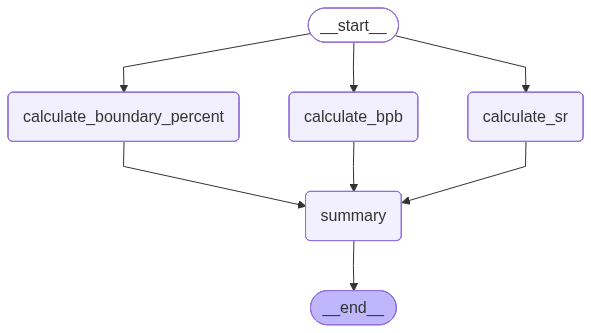

In [51]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [52]:
from langchain_groq import ChatGroq
model = ChatGroq(model="llama-3.3-70b-versatile", temperature=1)

In [53]:
from pydantic import BaseModel, Field
from typing import Annotated
import operator

In [54]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description='Detailed feedback for the essay')
    score: int = Field(description='Score out of 10', le=10, ge=0)

In [55]:
structured_model = model.with_structured_output(EvaluationSchema)

In [70]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    thought_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    average_score: float

In [71]:
def evaluate_language(state: UPSCState):

    prompt = f"Evaluate the language used in the following essay and provide detailed feedback along with a score out of 10:\n\n{state['essay']}"
    response = structured_model.invoke(prompt)
    return {
        'language_feedback': response.feedback, 
        'individual_scores': [response.score]
    }

In [72]:
def evaluate_analysis(state: UPSCState):

    prompt = f"Evaluate the analysis and arguments in the following essay and provide detailed feedback along with a score out of 10:\n\n{state['essay']}"
    response = structured_model.invoke(prompt)
    return {
        'analysis_feedback': response.feedback, 
        'individual_scores': [response.score]
    }

In [73]:
def evaluate_thought(state: UPSCState):

    prompt = f"Evaluate the thought process and reasoning in the following essay and provide detailed feedback along with a score out of 10:\n\n{state['essay']}"
    response = structured_model.invoke(prompt)
    return {
        'thought_feedback': response.feedback, 
        'individual_scores': [response.score]
    }

In [74]:
def final_evaluation(state: UPSCState):
    prompt = f"Based on the following feedback and scores, provide an overall evaluation of the essay along with an average score out of 10:\n\nLanguage Feedback: {state['language_feedback']}\nAnalysis Feedback: {state['analysis_feedback']}\nThought Feedback: {state['thought_feedback']}\nIndividual Scores: {state['individual_scores']}"
    overall_feedback = model.invoke(prompt)
    average_score = sum(state['individual_scores'])/len(state['individual_scores'])
    return {
        'overall_feedback': overall_feedback,
        'average_score': average_score
    }

In [75]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

In [76]:
initial_state = {
    'essay': "The impact of climate change on global agriculture is profound and multifaceted. Rising temperatures, altered precipitation patterns, and increased frequency of extreme weather events are affecting crop yields and food security worldwide. For instance, in regions like Sub-Saharan Africa, where agriculture is heavily reliant on rain-fed farming, changes in rainfall patterns have led to droughts and reduced agricultural productivity. Additionally, increased temperatures can stress crops and reduce yields, as seen in parts of South Asia. The essay effectively highlights the key issues and provides relevant examples, demonstrating a good understanding of the topic."
}
final_state = workflow.invoke(initial_state)
final_state

{'essay': 'The impact of climate change on global agriculture is profound and multifaceted. Rising temperatures, altered precipitation patterns, and increased frequency of extreme weather events are affecting crop yields and food security worldwide. For instance, in regions like Sub-Saharan Africa, where agriculture is heavily reliant on rain-fed farming, changes in rainfall patterns have led to droughts and reduced agricultural productivity. Additionally, increased temperatures can stress crops and reduce yields, as seen in parts of South Asia. The essay effectively highlights the key issues and provides relevant examples, demonstrating a good understanding of the topic.',
 'language_feedback': 'The essay demonstrates a clear and concise writing style, effectively conveying the impact of climate change on global agriculture. The use of transitional phrases and sentence structures is good, and the language is formal and suitable for an academic essay. The inclusion of specific examples

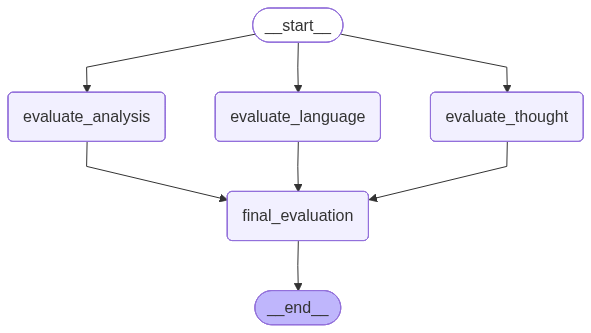

In [77]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())